In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from linearmodels.panel import PanelOLS, RandomEffects
import warnings
warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("data/processed")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Full panel (all years) for panel regression
ml_df = pd.read_csv(DATA_PROCESSED / "ea_ml_panel.csv")
ml_df = ml_df.sort_values(["country", "year"]).reset_index(drop=True)

# Train (pre-COVID) / Test (COVID + aftermath) split
train_df = pd.read_csv(DATA_PROCESSED / "ea_ml_train.csv")
test_df  = pd.read_csv(DATA_PROCESSED / "ea_ml_test.csv")

print("Full panel:", ml_df.shape)
print("Train (≤2019):", train_df.shape, "| Test (2020+):", test_df.shape)
ml_df.head()


Full panel: (109, 24)
Train (≤2019): (42, 24) | Test (2020+): (67, 24)


,country,year,birth_rate,birth_rate_change,mean_age_first_marriage,marriage_age_change,hpi_index,hicp_index,hpi_growth,hicp_growth,...,gdp_growth_lag1,unemp_rate_lag1,birth_rate_lag1,birth_rate_lag2,mean_age_first_marriage_lag1,mean_age_first_marriage_lag2,hpi_growth_roll3_mean,hicp_growth_roll3_mean,gdp_growth_roll3_mean,unemp_rate_roll3_mean
0,Austria,2017,10.0,0.0,32.85,0.20,112.14,103.22,5.088558,2.228385,...,2.1,6.033333,10.0,NaN,32.65,NaN,5.899279,1.599192,2.200000,5.750000
1,Austria,2018,9.7,-0.3,33.00,0.15,118.83,105.41,5.965757,2.121682,...,2.3,5.466667,10.0,10.0,32.85,32.65,5.921438,1.773356,2.300000,5.455556
2,Austria,2019,9.6,-0.1,33.35,0.35,125.97,106.98,6.008584,1.489422,...,2.5,4.866667,9.7,10.0,33.00,32.85,5.687633,1.946496,2.200000,4.944444
3,Austria,2023,8.5,-1.1,34.00,0.65,163.68,130.40,29.935699,21.891942,...,1.8,4.500000,9.6,9.7,33.35,33.00,13.970013,8.501016,1.166667,4.822222
4,Belgium,2022,9.8,-0.4,33.85,0.50,132.93,123.26,5.533503,10.339271,...,6.3,6.266667,10.2,NaN,33.35,NaN,6.098956,6.777323,5.150000,5.916667


In [12]:
# ── PART 1: Panel Fixed-Effects Regression ────────────────────────────────────
#
# Fixed effects control for time-invariant country characteristics (culture,
# institutions, baseline fertility). We use lagged macro variables as predictors
# so the direction is past macro → future demographic outcome, not the reverse.

panel_fe = ml_df.copy()
panel_fe = panel_fe.set_index(["country", "year"])

MACRO_LAGS = ["hpi_growth_lag1", "hicp_growth_lag1", "gdp_growth_lag1", "unemp_rate_lag1"]

# --- Birth rate ---
y_birth = panel_fe["birth_rate"]
X_birth = panel_fe[MACRO_LAGS].copy()
X_birth = X_birth.join(panel_fe[["birth_rate_lag1"]])  # autoregressive term

fe_birth = PanelOLS(y_birth, X_birth, entity_effects=True, time_effects=False)
res_birth = fe_birth.fit(cov_type="clustered", cluster_entity=True)
print("=== Fixed-Effects: Birth Rate ===")
print(res_birth.summary.tables[1])


=== Fixed-Effects: Birth Rate ===
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
hpi_growth_lag1   7.507e-05     0.0061     0.0124     0.9902     -0.0120      0.0121
hicp_growth_lag1    -0.0370     0.0102    -3.6324     0.0005     -0.0572     -0.0167
gdp_growth_lag1     -0.0181     0.0114    -1.5814     0.1174     -0.0408      0.0046
unemp_rate_lag1      0.0013     0.0153     0.0830     0.9341     -0.0292      0.0318
birth_rate_lag1      0.8844     0.0843     10.493     0.0000      0.7169      1.0520


In [13]:
# --- Marriage age ---
y_mar = panel_fe["mean_age_first_marriage"]
X_mar = panel_fe[MACRO_LAGS].copy()
X_mar = X_mar.join(panel_fe[["mean_age_first_marriage_lag1"]])  # autoregressive term

fe_mar = PanelOLS(y_mar, X_mar, entity_effects=True, time_effects=False)
res_mar = fe_mar.fit(cov_type="clustered", cluster_entity=True)
print("=== Fixed-Effects: Mean Age at First Marriage ===")
print(res_mar.summary.tables[1])


=== Fixed-Effects: Mean Age at First Marriage ===
                                      Parameter Estimates                                       
                              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------
hpi_growth_lag1                  0.0034     0.0056     0.5954     0.5531     -0.0079      0.0146
hicp_growth_lag1                 0.0080     0.0086     0.9280     0.3560     -0.0091      0.0250
gdp_growth_lag1                  0.0198     0.0082     2.4181     0.0177      0.0035      0.0360
unemp_rate_lag1                 -0.0566     0.0266    -2.1269     0.0363     -0.1095     -0.0037
mean_age_first_marriage_lag1     0.7456     0.0695     10.729     0.0000      0.6075      0.8838


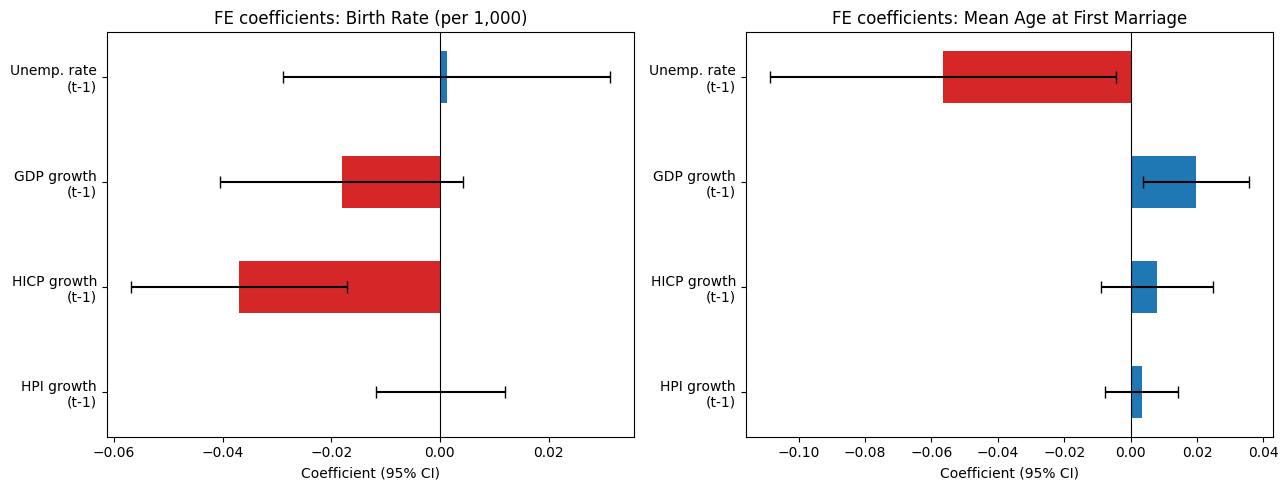

Saved fe_coefficients.png


In [14]:
# Coefficient plot for both FE models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, title in zip(
    axes,
    [res_birth, res_mar],
    ["Birth Rate (per 1,000)", "Mean Age at First Marriage"]
):
    params = res.params.drop("birth_rate_lag1", errors="ignore").drop("mean_age_first_marriage_lag1", errors="ignore")
    errs   = res.std_errors.loc[params.index] * 1.96
    labels = ["HPI growth\n(t-1)", "HICP growth\n(t-1)", "GDP growth\n(t-1)", "Unemp. rate\n(t-1)"]

    colors = ["#d62728" if v < 0 else "#1f77b4" for v in params.values]
    ax.barh(labels, params.values, xerr=errs.values, color=colors,
            error_kw={"capsize": 4}, height=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"FE coefficients: {title}")
    ax.set_xlabel("Coefficient (95% CI)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fe_coefficients.png", dpi=200)
plt.show()
print("Saved fe_coefficients.png")


In [15]:
# ── PART 2: Machine Learning Models ───────────────────────────────────────────
#
# Features: lagged macro variables + rolling means + autoregressive lag of target.
# Train: 2017-2019 (pre-COVID), Test: 2020-2024 (COVID + high-inflation period).
# This out-of-sample setup tests whether pre-COVID patterns still hold under stress.

FEATURES_BIRTH = [
    "hpi_growth_lag1", "hicp_growth_lag1", "gdp_growth_lag1", "unemp_rate_lag1",
    "hpi_growth_roll3_mean", "hicp_growth_roll3_mean",
    "gdp_growth_roll3_mean", "unemp_rate_roll3_mean",
    "birth_rate_lag1", "birth_rate_lag2",
]

FEATURES_MAR = [
    "hpi_growth_lag1", "hicp_growth_lag1", "gdp_growth_lag1", "unemp_rate_lag1",
    "hpi_growth_roll3_mean", "hicp_growth_roll3_mean",
    "gdp_growth_roll3_mean", "unemp_rate_roll3_mean",
    "mean_age_first_marriage_lag1", "mean_age_first_marriage_lag2",
]

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<30}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"model": name, "rmse": rmse, "r2": r2}

results = []


In [16]:
# --- Birth rate models ---
tr_b = train_df[FEATURES_BIRTH + ["birth_rate"]].dropna()
te_b = test_df[FEATURES_BIRTH + ["birth_rate"]].dropna()

X_tr_b, y_tr_b = tr_b[FEATURES_BIRTH].values, tr_b["birth_rate"].values
X_te_b, y_te_b = te_b[FEATURES_BIRTH].values, te_b["birth_rate"].values

scaler_b = StandardScaler().fit(X_tr_b)
X_tr_b_s = scaler_b.transform(X_tr_b)
X_te_b_s = scaler_b.transform(X_te_b)

ridge_b = Ridge(alpha=1.0).fit(X_tr_b_s, y_tr_b)
rf_b    = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(X_tr_b, y_tr_b)
gb_b    = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42).fit(X_tr_b, y_tr_b)

print("── Birth Rate ──────────────────────────────────────────")
results += [
    evaluate("Ridge",             y_te_b, ridge_b.predict(X_te_b_s)),
    evaluate("Random Forest",     y_te_b, rf_b.predict(X_te_b)),
    evaluate("Gradient Boosting", y_te_b, gb_b.predict(X_te_b)),
]


── Birth Rate ──────────────────────────────────────────
  Ridge                           RMSE=0.6058  R²=0.7441
  Random Forest                   RMSE=0.6127  R²=0.7383
  Gradient Boosting               RMSE=0.5647  R²=0.7776


In [17]:
# --- Marriage age models ---
tr_m = train_df[FEATURES_MAR + ["mean_age_first_marriage"]].dropna()
te_m = test_df[FEATURES_MAR + ["mean_age_first_marriage"]].dropna()

X_tr_m, y_tr_m = tr_m[FEATURES_MAR].values, tr_m["mean_age_first_marriage"].values
X_te_m, y_te_m = te_m[FEATURES_MAR].values, te_m["mean_age_first_marriage"].values

scaler_m = StandardScaler().fit(X_tr_m)
X_tr_m_s = scaler_m.transform(X_tr_m)
X_te_m_s = scaler_m.transform(X_te_m)

ridge_m = Ridge(alpha=1.0).fit(X_tr_m_s, y_tr_m)
rf_m    = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(X_tr_m, y_tr_m)
gb_m    = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42).fit(X_tr_m, y_tr_m)

print("── Mean Age at First Marriage ──────────────────────────")
results += [
    evaluate("Ridge",             y_te_m, ridge_m.predict(X_te_m_s)),
    evaluate("Random Forest",     y_te_m, rf_m.predict(X_te_m)),
    evaluate("Gradient Boosting", y_te_m, gb_m.predict(X_te_m)),
]


── Mean Age at First Marriage ──────────────────────────
  Ridge                           RMSE=0.4318  R²=0.9493
  Random Forest                   RMSE=0.6210  R²=0.8951
  Gradient Boosting               RMSE=0.5850  R²=0.9069


In [18]:
# Model comparison table
metrics_df = pd.DataFrame(results)
metrics_df.insert(0, "target", ["Birth Rate"]*3 + ["Marriage Age"]*3)
metrics_df = metrics_df.round(4)
print(metrics_df.to_string(index=False))
metrics_df.to_csv(DATA_PROCESSED / "model_metrics.csv", index=False)


      target             model   rmse     r2
  Birth Rate             Ridge 0.6058 0.7441
  Birth Rate     Random Forest 0.6127 0.7383
  Birth Rate Gradient Boosting 0.5647 0.7776
Marriage Age             Ridge 0.4318 0.9493
Marriage Age     Random Forest 0.6210 0.8951
Marriage Age Gradient Boosting 0.5850 0.9069


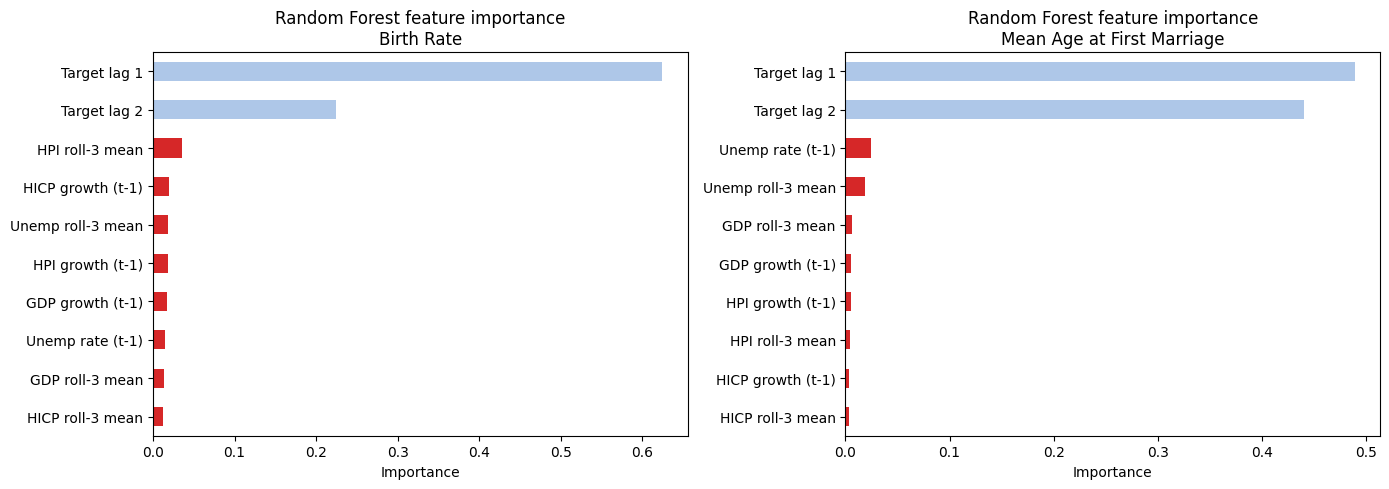

Saved rf_feature_importance.png


In [19]:
# Feature importance — Random Forest (best interpretable tree model)
MACRO_LABELS = [
    "HPI growth (t-1)", "HICP growth (t-1)", "GDP growth (t-1)", "Unemp rate (t-1)",
    "HPI roll-3 mean", "HICP roll-3 mean", "GDP roll-3 mean", "Unemp roll-3 mean",
    "Target lag 1", "Target lag 2",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rf, labels, title in zip(
    axes,
    [rf_b, rf_m],
    [MACRO_LABELS, MACRO_LABELS],
    ["Birth Rate", "Mean Age at First Marriage"],
):
    imp = pd.Series(rf.feature_importances_, index=labels).sort_values(ascending=True)
    colors = ["#d62728" if "lag" not in l.lower() else "#aec7e8" for l in imp.index]
    imp.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"Random Forest feature importance\n{title}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(FIG_DIR / "rf_feature_importance.png", dpi=200)
plt.show()
print("Saved rf_feature_importance.png")


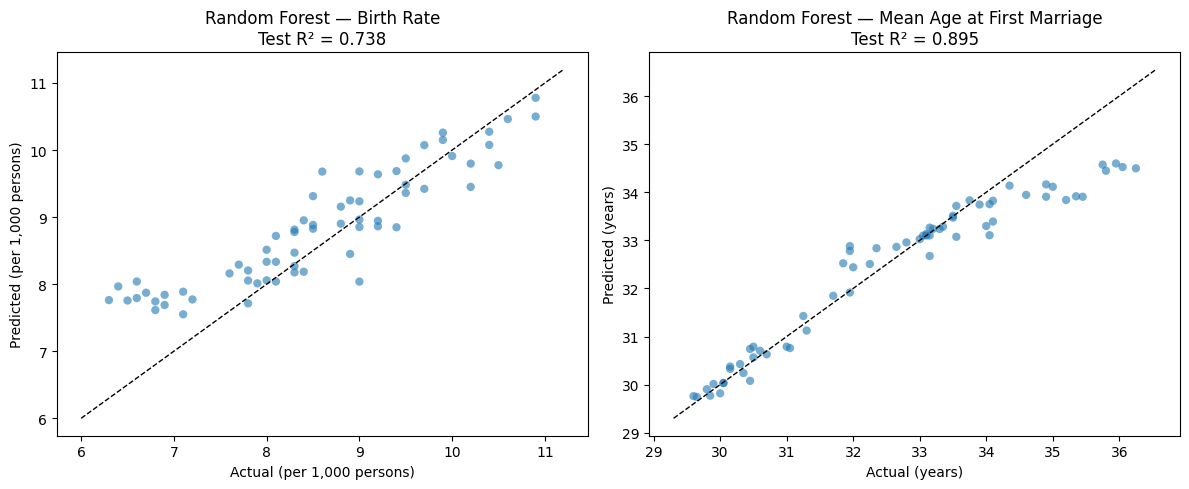

Saved rf_actual_vs_predicted.png


In [20]:
# Actual vs predicted — best model per target (Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, rf, X_te, y_te, title, unit in zip(
    axes,
    [rf_b, rf_m],
    [X_te_b, X_te_m],
    [y_te_b, y_te_m],
    ["Birth Rate", "Mean Age at First Marriage"],
    ["per 1,000 persons", "years"],
):
    y_hat = rf.predict(X_te)
    ax.scatter(y_te, y_hat, alpha=0.6, edgecolors="none")
    lim = [min(y_te.min(), y_hat.min()) - 0.3, max(y_te.max(), y_hat.max()) + 0.3]
    ax.plot(lim, lim, "k--", linewidth=1)
    ax.set_xlabel(f"Actual ({unit})")
    ax.set_ylabel(f"Predicted ({unit})")
    r2 = r2_score(y_te, y_hat)
    ax.set_title(f"Random Forest — {title}\nTest R² = {r2:.3f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "rf_actual_vs_predicted.png", dpi=200)
plt.show()
print("Saved rf_actual_vs_predicted.png")
